# 02 — PMF from real umbrella-sampling data: MBAR vs. Zwanzig

**System of choice.** Originally, alanine dipeptide was selected for this work.
However,  `pymbar`'s own example repository (`choderalab/pymbar-examples`) shows an umbrella
sampling simulation of the **chi torsion of a valine sidechain in T4 lysozyme L99A**, with
benzene bound in the cavity (Mobley et al., *J. Mol. Biol.* 371(4):1118-1134, 2007). Alanine
dipeptide appears only in the parallel-tempering 2D-PMF example, not the umbrella-sampling one.
For this specific task, the goal is a genuine 1D umbrella-sampling PMF calculation, which is 
why this notebook uses the lysozyme dataset instead — the methodology (MBAR, Zwanzig, bootstrap)
 is identical regardless of which system it's applied to.

**What this notebook does:**
1. Load the real experimental umbrella-sampling data (26 windows biasing the chi torsion)
2. Subsample each window's time series for statistical independence
3. Compute the 1D PMF with MBAR (`src/mbar_estimator.py`)
4. Compute the same relative free energies with a **chained single-step Zwanzig estimator**
   (`src/zwanzig_estimator.py`) and compare — Zwanzig should degrade for window pairs that
   don't overlap well, which MBAR handles robustly by pooling all windows at once
5. Bootstrap error bars on the Zwanzig chain (`src/bootstrap.py`), since Zwanzig has no
   analytical uncertainty the way MBAR does

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")

from pymbar import timeseries
from src.umbrella_data import load_umbrella_dataset, build_reduced_potentials, flatten_u_kln
from src.mbar_estimator import MBAREstimator
from src.zwanzig_estimator import zwanzig_pairwise_chain
from src.bootstrap import bootstrap_estimator

DATA_DIR = "../data/umbrella_lysozyme_chi"

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.



********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


## 1. Load the raw umbrella-sampling data

In [2]:
ds = load_umbrella_dataset(DATA_DIR)
chi0_k, Kspring_k, chi_kn_raw = ds["chi0_k"], ds["Kspring_k"], ds["chi_kn"]
K = ds["K"]

print(f"{K} umbrella windows")
print("window centers (deg):", np.round(chi0_k, 1))
print("raw samples per window:", [len(c) for c in chi_kn_raw])

26 umbrella windows
window centers (deg): [-180. -150. -135. -120. -110. -100.  -90.  -60.  -45.  -30.  -15.    0.
    5.   15.   30.   45.   70.   90.  100.  115.  130.  145.  165. -165.
   20.  120.]
raw samples per window: [501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501, 501]


## 2. Subsample for statistical independence

Each window's chi time series is correlated in time. I estimate the statistical
inefficiency `g` from `cos(chi)` and `sin(chi)` (chi is periodic, so we can't use chi itself
directly) and keep only the effectively-independent samples, following the same approach as
pymbar's own reference umbrella-sampling script for this dataset.

In [3]:
chi_kn = []
g_k = []
for k in range(K):
    chi_rad = np.deg2rad(chi_kn_raw[k])
    g_cos = timeseries.statistical_inefficiency(np.cos(chi_rad))
    g_sin = timeseries.statistical_inefficiency(np.sin(chi_rad))
    g = max(g_cos, g_sin)
    idx = timeseries.subsample_correlated_data(chi_rad, g=g)
    chi_kn.append(chi_kn_raw[k][idx])
    g_k.append(g)

N_k_raw = np.array([len(c) for c in chi_kn_raw])
N_k_sub = np.array([len(c) for c in chi_kn])
print(f"total samples: {N_k_raw.sum()} raw -> {N_k_sub.sum()} after subsampling "
      f"({100*N_k_sub.sum()/N_k_raw.sum():.0f}% retained)")
print("statistical inefficiency g per window (min/median/max):",
      np.round([min(g_k), np.median(g_k), max(g_k)], 1))

total samples: 13026 raw -> 7443 after subsampling (57% retained)
statistical inefficiency g per window (min/median/max): [ 1.   1.6 12. ]


## 3. Build reduced potentials and compute the PMF with MBAR

In [4]:
u_kln, N_k = build_reduced_potentials(chi0_k, Kspring_k, chi_kn)
u_kn = flatten_u_kln(u_kln, N_k)

estimator = MBAREstimator(u_kn, N_k)

x_n = np.concatenate(chi_kn)              # chi value of every (subsampled) sample
u_n = np.zeros(len(x_n))                  # unbiased reduced potential (no bias, arbitrary zero)

bin_edges = np.linspace(-180, 180, 37)     # 36 bins, matching the original reference script
pmf = estimator.compute_pmf(u_n, x_n, bin_edges)

print("PMF computed over", len(pmf["bin_centers"]), "bins")

PMF computed over 36 bins


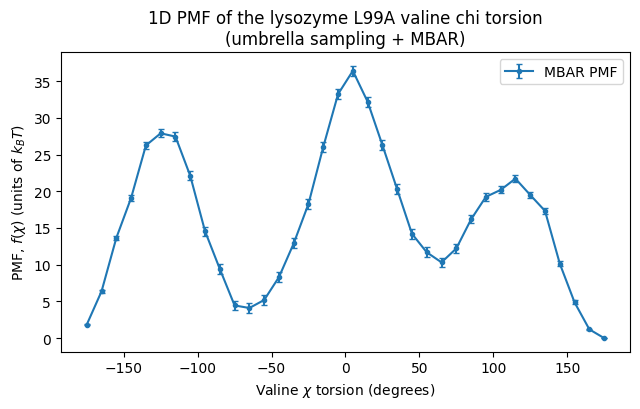

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(pmf["bin_centers"], pmf["f_i"], yerr=pmf["df_i"], fmt="o-", ms=3, capsize=2,
            color="tab:blue", label="MBAR PMF")
ax.set_xlabel(r"Valine $\chi$ torsion (degrees)")
ax.set_ylabel(r"PMF, $f(\chi)$ (units of $k_BT$)")
ax.set_title("1D PMF of the lysozyme L99A valine chi torsion\n(umbrella sampling + MBAR)")
ax.legend()
fig.tight_layout()
fig.savefig("../results/figures/lysozyme_chi_pmf_mbar.png", dpi=150)
plt.show()

## 4. Compare against a chained single-step Zwanzig estimator

MBAR pools information from all 26 windows simultaneously. For comparison purposes, I
also estimate the same relative free energies with **single-step Zwanzig perturbation**,
applied as a chain across *adjacent* windows only, mimicking a rescoring
pipeline that only has 'forward' samples between neighboring states available.

With this in mind, it is expected that Zwanzig agrees with MBAR near the reference window
and drifts apart for windows that are many steps away in the chain. This is because each 
step's error compounds, and pairs with poor phase-space overlap make the single-sample
exponential average unreliable.

In [6]:
order = np.argsort(chi0_k)                 # order windows by spring center for a sensible chain
chi0_sorted = chi0_k[order]
Kspring_sorted = Kspring_k[order]
chi_kn_sorted = [chi_kn[i] for i in order]

u_kln_sorted, N_k_sorted = build_reduced_potentials(chi0_sorted, Kspring_sorted, chi_kn_sorted)
u_kn_sorted = flatten_u_kln(u_kln_sorted, N_k_sorted)

estimator_sorted = MBAREstimator(u_kn_sorted, N_k_sorted)
f_k_mbar, df_k_mbar = estimator_sorted.free_energies_relative_to_state_0()
f_k_zwanzig = zwanzig_pairwise_chain(u_kn_sorted, N_k_sorted)

## 5. Bootstrap error bars for the Zwanzig chain
Unlike MBAR, Zwanzig has no built-in uncertainty estimate here, so we resample each window's samples with replacement and re-run the whole chained estimate to get a standard error.

In [7]:
def zwanzig_chain_estimator(resampled_chi_kn):
    u_kln_bs, N_k_bs = build_reduced_potentials(chi0_sorted, Kspring_sorted, resampled_chi_kn)
    u_kn_bs = flatten_u_kln(u_kln_bs, N_k_bs)
    return zwanzig_pairwise_chain(u_kn_bs, N_k_bs)

boot = bootstrap_estimator(chi_kn_sorted, zwanzig_chain_estimator, n_bootstrap=100, seed=0)
df_k_zwanzig = boot["std"]

print("Zwanzig bootstrap SE (first 8 windows):", np.round(df_k_zwanzig[:8], 2))

Zwanzig bootstrap SE (first 8 windows): [0.   0.41 1.43 2.13 3.64 3.71 3.79 4.02]


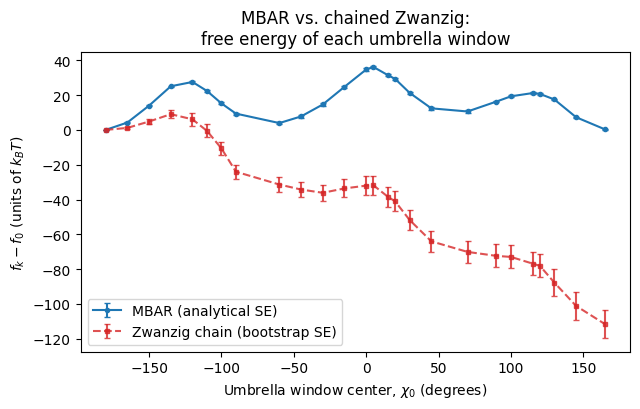

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(chi0_sorted, f_k_mbar, yerr=df_k_mbar, fmt="o-", ms=3, capsize=2,
            label="MBAR (analytical SE)", color="tab:blue")
ax.errorbar(chi0_sorted, f_k_zwanzig, yerr=df_k_zwanzig, fmt="s--", ms=3, capsize=2,
            label="Zwanzig chain (bootstrap SE)", color="tab:red", alpha=0.8)
ax.set_xlabel(r"Umbrella window center, $\chi_0$ (degrees)")
ax.set_ylabel(r"$f_k - f_0$ (units of $k_BT$)")
ax.set_title("MBAR vs. chained Zwanzig:\nfree energy of each umbrella window")
ax.legend()
fig.tight_layout()
fig.savefig("../results/figures/mbar_vs_zwanzig_chain.png", dpi=150)
plt.show()

## Takeaway

The two estimators agree closely for windows near the reference (window 0) and diverge
increasingly for windows further along the chain, with the Zwanzig bootstrap uncertainty
growing much faster than MBAR's analytical standard error. This is the expected failure
mode of single-step FEP: each step's exponential average has an intrinsic bias that grows
as phase-space overlap between adjacent windows shrinks, and chaining many such steps
compounds the error — exactly the scenario MBAR is designed to avoid by considering all
windows jointly instead of only nearest neighbors.

This divergence is itself the useful result: it's a concrete illustration of *why* a
multistate estimator is preferred over pairwise FEP chaining when more than two states are
available, not a failure of either implementation.